### Persiapan dan analist data apakah benar / salah

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("dataAnalist.csv")
print(df.head())
df.isnull().sum()

   Order_ID  CustomerID  Order_Date Product_Category  Quantity  \
0      1001        5039  2023-08-19            Books         4   
1      1002        5029  2023-08-29          Fashion         5   
2      1003        5015  2023-02-21          Fashion         4   
3      1004        5043  2023-04-06          Fashion         2   
4      1005        5008  2023-08-10       Home Decor         2   

   Price_Per_Unit  Ad_Budget  Total_Sales  
0       1184000.0   982000.0    4736000.0  
1       1733000.0  3513000.0    8665000.0  
2       1767000.0  2117000.0    7068000.0  
3        512000.0  4384000.0    1024000.0  
4       1820000.0  2625000.0    3640000.0  


Order_ID            0
CustomerID          0
Order_Date          0
Product_Category    0
Quantity            0
Price_Per_Unit      0
Ad_Budget           0
Total_Sales         7
dtype: int64

### Anaalisis Tren Penjualan Bulalan

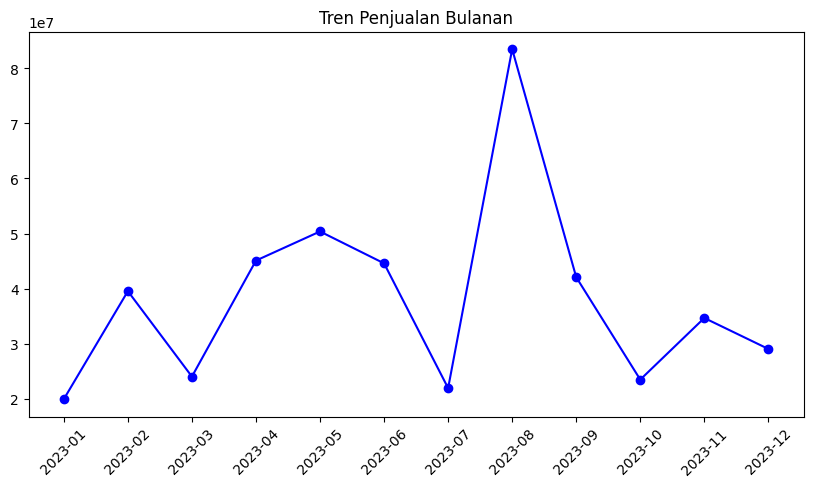

In [25]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)
monthly_sales = df.groupby("Month")["Total_Sales"].sum()

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o", color="b")
plt.title("Tren Penjualan Bulanan")
plt.xticks(rotation=45)
plt.show()

### analisis korelasi (Heatmap)

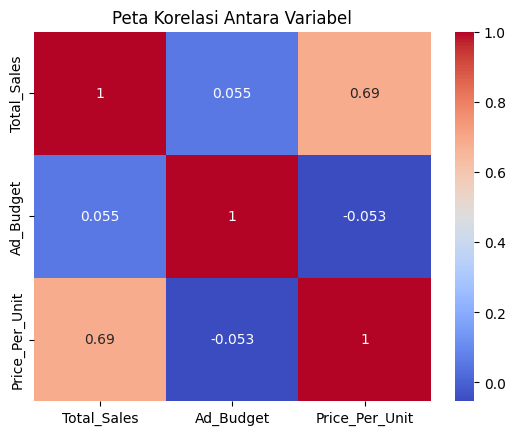

In [27]:
correlation = df[['Total_Sales', 'Ad_Budget', 'Price_Per_Unit']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Peta Korelasi Antara Variabel')
plt.show()

## Tugas Analis Produk "Underperformer"

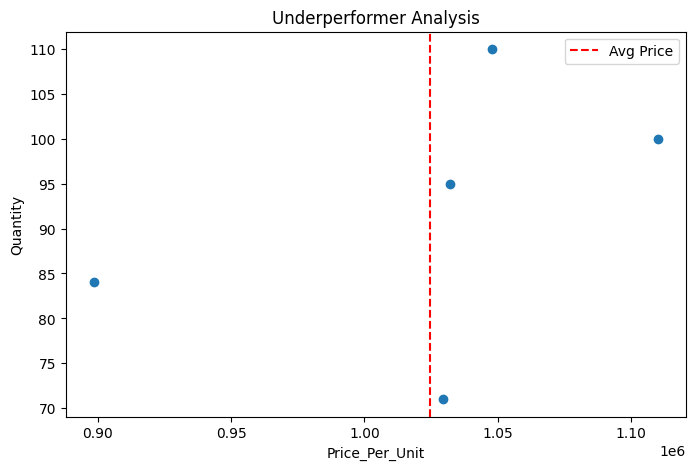

===== ANALISIS UNDERPERFORMER =====

Rata-rata harga produk: 1024640.00

Daftar kategori dengan harga di atas rata-rata:
  Product_Category  Price_Per_Unit  Quantity
0            Books    1.047941e+06       110
1      Electronics    1.109871e+06       100
2          Fashion    1.032000e+06        95
4       Home Decor    1.029583e+06        71

Penjelasan:
- Kategori di atas memiliki harga lebih tinggi dari rata-rata.
- Jika quantity rendah, maka kategori tersebut termasuk underperformer.
- Hal ini bisa disebabkan oleh harga terlalu mahal atau kurang diminati pasar.

Kategori paling berpotensi UNDERPERFORMER:
  Product_Category  Price_Per_Unit  Quantity
4       Home Decor    1.029583e+06        71

Rekomendasi:
- Pertimbangkan penyesuaian harga (diskon / bundling).
- Evaluasi strategi pemasaran pada kategori tersebut.
- Analisis apakah produk sesuai dengan target market.


In [37]:
avg_price = df['Price_Per_Unit'].mean()

product_summary = df.groupby('Product_Category').agg({
    'Price_Per_Unit': 'mean',
    'Quantity': 'sum'
}).reset_index()

underperformer = product_summary[
    (product_summary['Price_Per_Unit'] > avg_price)
]

plt.figure(figsize=(8,5))
plt.scatter(product_summary['Price_Per_Unit'], product_summary['Quantity'])

plt.axvline(avg_price, color='red', linestyle='--', label='Avg Price')

plt.xlabel('Price_Per_Unit')
plt.ylabel('Quantity')
plt.title('Underperformer Analysis')
plt.legend()
plt.show()


print("===== ANALISIS UNDERPERFORMER =====\n")

print(f"Rata-rata harga produk: {avg_price:.2f}\n")

print("Daftar kategori dengan harga di atas rata-rata:")
print(underperformer)

print("\nPenjelasan:")
print("- Kategori di atas memiliki harga lebih tinggi dari rata-rata.")
print("- Jika quantity rendah, maka kategori tersebut termasuk underperformer.")
print("- Hal ini bisa disebabkan oleh harga terlalu mahal atau kurang diminati pasar.")

worst = underperformer.sort_values(by='Quantity').head(1)

print("\nKategori paling berpotensi UNDERPERFORMER:")
print(worst)

print("\nRekomendasi:")
print("- Pertimbangkan penyesuaian harga (diskon / bundling).")
print("- Evaluasi strategi pemasaran pada kategori tersebut.")
print("- Analisis apakah produk sesuai dengan target market.")

In [38]:
import datetime as dt
import pandas as pd

# Pastikan format tanggal
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Tentukan snapshot date
snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)

# Hitung RFM
rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'count',
    'Total_Sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# ================= SCORING (AMAN ERROR) =================
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1], duplicates='drop')
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5], duplicates='drop')
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5], duplicates='drop')

# Gabungkan
rfm['RFM_Group'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# ================= OUTPUT =================
print("===== RFM ANALYSIS =====\n")
print(rfm.head())

# ================= INSIGHT =================

print("\n===== INSIGHT =====")

# Top customer (terbaik)
best_customer = rfm.sort_values(by=['Monetary','Frequency'], ascending=False).head(3)

print("\nTop 3 Pelanggan Terbaik:")
print(best_customer)

# Customer berisiko hilang
lost_customer = rfm.sort_values(by=['Recency'], ascending=False).head(3)

print("\nPelanggan Berisiko Hilang:")
print(lost_customer)

# Segment sederhana
print("\nPenjelasan Segment:")
print("- Skor tinggi (5) = performa bagus")
print("- R tinggi = baru belanja")
print("- F tinggi = sering belanja")
print("- M tinggi = banyak uang dibelanjakan")

# Distribusi segment
print("\nDistribusi RFM Group:")
print(rfm['RFM_Group'].value_counts().head())

===== RFM ANALYSIS =====

            Recency  Frequency    Monetary R_Score F_Score M_Score RFM_Group
CustomerID                                                                  
5001            213          4   8562000.0       1       4       3       143
5002             77          4   6931000.0       3       4       3       343
5003            118          3   9433000.0       3       2       3       323
5004            196          3  15368000.0       2       3       4       234
5005             23          2   9105000.0       5       2       3       523

===== INSIGHT =====

Top 3 Pelanggan Terbaik:
            Recency  Frequency    Monetary R_Score F_Score M_Score RFM_Group
CustomerID                                                                  
5015             21          6  26309000.0       5       5       5       555
5008             15          6  22350000.0       5       5       5       555
5035             53          6  22066000.0       4       5       5       455

Pe

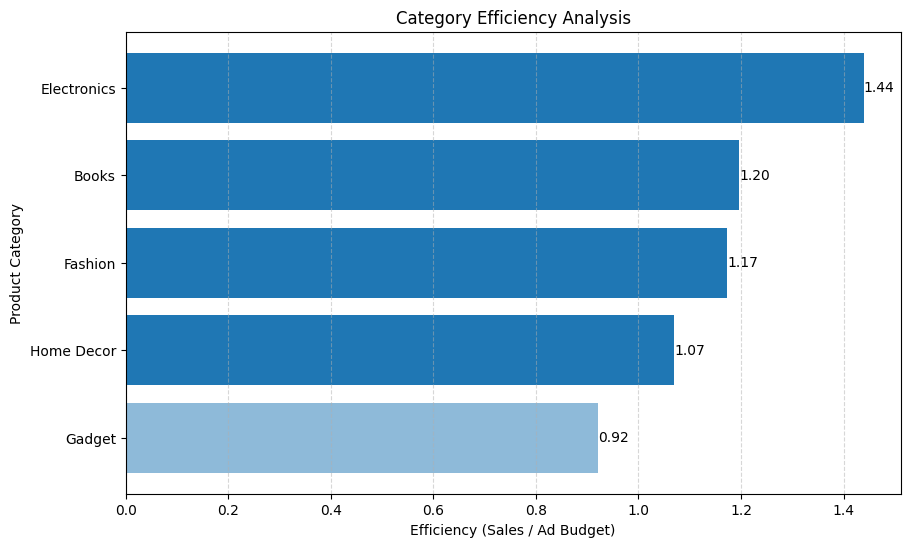

Kategori paling tidak efisien:
  Product_Category  Total_Sales   Ad_Budget  Efficiency
3           Gadget   70523000.0  76539000.0      0.9214

Kategori paling efisien:
  Product_Category  Total_Sales   Ad_Budget  Efficiency
1      Electronics  114095000.0  79264000.0     1.43943


In [35]:
category_perf = df.groupby('Product_Category').agg({
    'Total_Sales': 'sum',
    'Ad_Budget': 'sum'
}).reset_index()

# Hindari pembagian nol
category_perf['Efficiency'] = category_perf['Total_Sales'] / category_perf['Ad_Budget'].replace(0, 1)

# Urutkan dari paling tidak efisien
category_perf = category_perf.sort_values(by='Efficiency')

# Plot
plt.figure(figsize=(10,6))
bars = plt.barh(category_perf['Product_Category'], category_perf['Efficiency'])

# Tambahkan label angka di setiap bar
for i, v in enumerate(category_perf['Efficiency']):
    plt.text(v, i, f"{v:.2f}", va='center')

# Highlight kategori paling tidak efisien (opsional)
bars[0].set_alpha(0.5)

plt.xlabel('Efficiency (Sales / Ad Budget)')
plt.ylabel('Product Category')
plt.title('Category Efficiency Analysis')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()
print("Kategori paling tidak efisien:")
print(category_perf.head(1))

print("\nKategori paling efisien:")
print(category_perf.tail(1))